# **1. Load the datasets**

In [1]:
import pandas as pd
from collections import defaultdict
import numpy as np
import json
from translatepy import Translator

In [2]:
def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

articles = load_jsonl("data/articles.jsonl")
summaries = load_jsonl("data/summaries.jsonl")

---

# **2. Data analysis (general)**

#### Let's observe articles and summaries

In [3]:
articles[0]

{'article_id': '50469832',
 'url': 'https://www.bbc.com/japanese/50469832',
 'title': 'イスラエル入植地「違法ではない」 米政府が方針転換',
 'text': 'イスラエルは東エルサレムを含むヨルダン川西岸に、100カ所以上のユダヤ人入植地を建設してきた マイク・ポンペオ国務長官が記者会見で、ヨルダン川西岸の地位は、イスラエルとパレスチナが交渉すべきものとの見解を示した。 「アメリカは法的論争をすべての面から慎重に検討した結果、イスラエル民間人によるヨルダン川西岸の入植地建設はただちに、国際法に則っていないというわけではないとの結論に達した」 ポンペオ氏はまた、「民間人の入植地建設を国際法に則していないと指摘する方法では、うまくいかなかった。平和の促進につながらなかった」と述べた。 「歴史の過ちを正す」 イスラエルは、アメリカによるこの方針転換を歓迎した。 ベンヤミン・ネタニヤフ首相は、ドナルド・トランプ米政権による方針転換は「歴史の過ちを正す」ものだと評価。他国も続くよう求めた。 イスラエルのネタニヤフ首相は、入植地を手放すことは決してないとしている 一方、パレスチナ解放機構（PLO）の交渉担当者サエブ・エレカット氏は、アメリカの決定を「世界の安定と安全、平和」を危険にさらすものと批判。 国際法を「ジャングル法」に変えてしまう恐れがあると述べた。 140の入植地に60万人 イスラエルによるパレスチナ自治区での入植地建設は長年、同国と国際社会、パレスチナの間における論争の原因となっている。 イスラエルは1967年の第3次中東戦争後、入植地を建設してきた。現在、約140の入植地があり、計約60万人のユダヤ人が居住している。 入植地は一般的に、国際法に照らして違法だと考えられている。ただ、イスラエルは一貫してこの見方に異を唱えている。 パレスチナは長年、すべての入植地の撤廃を要求してきた。将来、独立したパレスチナ国家となるべき土地に入植地があると、国家建設がほぼ実現不可能になると主張している。 オバマ政権はイスラエル擁護せず アメリカは1978年、ジミー・カーター政権で、イスラエルの入植地建設は国際法違反と結論づけた。しかし1981年には、ロナルド・レーガン大統領がこの結論に不同意を

In [4]:
summaries[1]

{'summary_id': '34991666_7b3a10b0',
 'article_id': '34991666',
 'summary': '米カリフォルニア州サンバーナディーノの福祉施設で2日、銃の乱射事件があり、少なくとも14人が死亡、17人が負傷した。実行犯は現場から逃走したが、'}

---

#### Double check about the size of each dataset

In [5]:
print(len(articles))
print(len(summaries))

50
250


---

#### Ok, we have the expected amount. Now, let's convert it as dataframes for further analysis

In [6]:
df_articles = pd.DataFrame(articles)
df_articles.head()

,article_id,url,title,text,reference_summary
0,50469832,https://www.bbc.com/japanese/50469832,イスラエル入植地「違法ではない」 米政府が方針転換,イスラエルは東エルサレムを含むヨルダン川西岸に、100カ所以上のユダヤ人入植地を建設してきた...,アメリカ政府は18日、パレスチナ自治区ヨルダン川西岸でイスラエル政府が建設してきた入植地につ...
1,38476572,https://www.bbc.com/japanese/38476572,シリア停戦合意、ほぼ持続 国連安保理は投票へ,ダマスカス郊外ドゥーマで30日に砲撃があったと反政府勢力は主張している。写真は、反政府勢力が...,シリア全土で30日午前零時（日本時間午前7時）に発効した政府軍と反政府勢力の停戦合意は、散発...
2,48493511,https://www.bbc.com/japanese/48493511,天安門事件の鎮圧は「正しい」と中国国防相 30周年を前に異例の言及,天安門事件から30年 中国が忘れた映像 魏氏はシンガポールで開かれた会合で、聴衆から天安門事...,中国で起きた天安門事件から6月4日で30年を迎えるのを前に、同国の魏鳳和（ウェイ・フォンホー...
3,39776572,https://www.bbc.com/japanese/39776572,米人気コメディアン、息子が九死に一生を得たと,今年2月のアカデミー賞授賞式を司会したジミー・キメルさん キメルさんは番組冒頭で、4月21日...,米トーク番組やアカデミー賞授賞式などの司会で人気のコメディアン、ジミー・キメルさんが1日夜放...
4,53274336,https://www.bbc.com/japanese/53274336,韓国のトライアスロン選手が自殺、コーチらが長年暴力か,韓国女子トライアスロンのチェ・スクヒョン選手 報道によると、スクヒョン選手は暴行についてスポ...,コーチらから長年暴行を受けていたと訴えていた韓国の女子トライアスロン選手のチェ・スクヒョン氏...


In [7]:
df_articles.shape

(50, 5)

In [8]:
df_articles.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   article_id         50 non-null     object
 1   url                50 non-null     object
 2   title              50 non-null     object
 3   text               50 non-null     object
 4   reference_summary  50 non-null     object
dtypes: object(5)
memory usage: 2.1+ KB


In [9]:
df_articles.describe()

,article_id,url,title,text,reference_summary
count,50,50,50,50,50
unique,50,50,50,50,50
top,50469832,https://www.bbc.com/japanese/50469832,イスラエル入植地「違法ではない」 米政府が方針転換,イスラエルは東エルサレムを含むヨルダン川西岸に、100カ所以上のユダヤ人入植地を建設してきた...,アメリカ政府は18日、パレスチナ自治区ヨルダン川西岸でイスラエル政府が建設してきた入植地につ...
freq,1,1,1,1,1


No NaN values and 50 unique articles, now, we will see about the summaries:

In [10]:
df_summaries = pd.DataFrame(summaries)
df_summaries.head()

,summary_id,article_id,summary
0,34991666_52f88088,34991666,米カリフォルニア州サンバーナディーノの福祉施設で2日、銃の乱射事件が発生し少なくとも14人が...
1,34991666_7b3a10b0,34991666,米カリフォルニア州サンバーナディーノの福祉施設で2日、銃の乱射事件があり、少なくとも14人が...
2,34991666_c1f887ae,34991666,乱射事件現場の警察特殊部隊 調べによると、銃撃犯たちは戦闘服のような服装で施設に乱入し、銃を...
3,34991666_eb217fa8,34991666,米カリフォルニア州サンバーナディーノの福祉施設で2日、銃の乱射事件があり、少なくとも14人が...
4,34991666_f6f8e339,34991666,米カリフォルニア州サンバーナディーノの福祉施設で2日、銃の乱射事件が発生し少なくとも14人が...


In [11]:
df_summaries.shape

(250, 3)

In [12]:
df_summaries.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   summary_id  250 non-null    object
 1   article_id  250 non-null    object
 2   summary     250 non-null    object
dtypes: object(3)
memory usage: 6.0+ KB


In [13]:
df_summaries.describe()

,summary_id,article_id,summary
count,250,250,250
unique,250,50,226
top,34991666_52f88088,34991666,シリア全土で30日午前零時（日本時間午前7時）に発効した政府軍と反政府勢力の停戦合意は、散発...
freq,1,5,4


No NaN values as well, but only 226 unique summaries, which means some are duplicates.

---

#### We want to see if there is exactly 5 summaries per article (and  not for exemple, an article with 4 summaries and another with 6):

In [14]:
counts = df_summaries.groupby("article_id").size()

exactly_5_unique_summaries = (counts == 5).all()
print(exactly_5_unique_summaries)

True


---

# **3. Data analysis (focus on text)**

#### We will translate articles and summaries in French to have a closer look:

In [15]:
translator = Translator()
result = translator.translate(summaries[1]["summary"], "French")
print(result.result)

Au moins 14 personnes ont été tuées et 17 autres blessées dans une fusillade de masse dans une résidence-services à San Bernardino, en Californie, le 2. L'agresseur a pris la fuite, mais


In [16]:
for article in articles:
    for key, value in article.items():
        french_value = translator.translate(value, "French")

In [17]:
def translate_list(list, target_lang="French"):

    translator = Translator()
    french_articles = []

    for element in list:
        french_article = {}

        for key, value in element.items():
            if isinstance(value, str):
                try:
                    french_value = translator.translate(value, target_lang).result
                except Exception:
                    french_value = value
            else:
                french_value = value

            french_article[key] = french_value

        french_articles.append(french_article)

    return french_articles

In [18]:
french_articles = translate_list(articles)
french_summaries = translate_list(summaries)

In [19]:
french_articles

[{'article_id': '50469832',
  'url': 'https://www.bbc.com/japanese/50469832',
  'title': 'Les colonies israéliennes « ne sont pas illégales » Le gouvernement américain change de politique',
  'text': 'Israël a construit plus de 100 colonies juives en Cisjordanie, y compris à Jérusalem-Est. Le secrétaire d\'État Mike Pompeo a déclaré lors d\'une conférence de presse que le statut de la Cisjordanie devait être négocié entre Israël et les Palestiniens."Après avoir soigneusement examiné tous les aspects de la controverse juridique, les Etats-Unis ont rapidement conclu que la construction de colonies en Cisjordanie par des civils israéliens n\'est pas incompatible avec le droit international", a déclaré Pompeo. « Réparer les torts de l\'histoire » Israël a salué ce changement de politique des États-Unis.Le Premier ministre Benjamin Netanyahu a déclaré que le changement de politique de l\'administration du président américain Donald Trump « réparerait les torts de l\'histoire ».Il a exhorté 

In [20]:
french_summaries

[{'summary_id': '34991666_52f88088',
  'article_id': '34991666',
  'summary': "Au moins 14 personnes ont été tuées et 17 autres blessées dans une fusillade de masse dans une résidence-services à San Bernardino, en Californie, le 2. Les deux agresseurs, un homme et une femme, ont été tués lors d'une fusillade avec la police après avoir pris la fuite."},
 {'summary_id': '34991666_7b3a10b0',
  'article_id': '34991666',
  'summary': "Au moins 14 personnes ont été tuées et 17 autres blessées dans une fusillade de masse dans une résidence-services à San Bernardino, en Californie, le 2. L'agresseur a pris la fuite, mais"},
 {'summary_id': '34991666_c1f887ae',
  'article_id': '34991666',
  'summary': "Les forces spéciales de la police sur les lieux d'une fusillade massive Selon l'enquête, les hommes armés ont fait irruption dans l'établissement portant ce qui semblait être des uniformes de combat, ont tiré des coups de feu puis se sont enfuis à bord d'un SUV noir.Environ quatre heures après l'

In [21]:
summaries

[{'summary_id': '34991666_52f88088',
  'article_id': '34991666',
  'summary': '米カリフォルニア州サンバーナディーノの福祉施設で2日、銃の乱射事件が発生し少なくとも14人が死亡、17人が負傷した。犯人の男女2人は現場から逃走した後、警察との銃撃戦で死亡した。'},
 {'summary_id': '34991666_7b3a10b0',
  'article_id': '34991666',
  'summary': '米カリフォルニア州サンバーナディーノの福祉施設で2日、銃の乱射事件があり、少なくとも14人が死亡、17人が負傷した。実行犯は現場から逃走したが、'},
 {'summary_id': '34991666_c1f887ae',
  'article_id': '34991666',
  'summary': '乱射事件現場の警察特殊部隊 調べによると、銃撃犯たちは戦闘服のような服装で施設に乱入し、銃を乱射したのち黒いSUV（多目的スポーツ車）で逃走。事件発生から約4時間後、市内の住宅地で窓を撃ち抜かれた黒いSUVを警官隊が包囲した。このSUVと乱射事件の関連について警察は明らかにしていないが、現場で1人が射殺されたという。'},
 {'summary_id': '34991666_eb217fa8',
  'article_id': '34991666',
  'summary': '米カリフォルニア州サンバーナディーノの福祉施設で2日、銃の乱射事件があり、少なくとも14人が死亡、17人が負傷した。実行犯は現場から逃走したが、その後警察との銃撃戦で武装した男と女の2人が死亡した。現場のインランド地域センターは障害のある大人を支援する医療施設。'},
 {'summary_id': '34991666_f6f8e339',
  'article_id': '34991666',
  'summary': '米カリフォルニア州サンバーナディーノの福祉施設で2日、銃の乱射事件が発生し少なくとも14人が死亡、17人が負傷した。犯人の男女2人は現場から逃走後、他州へ逃亡し引き続き警察の捜索対象となっている。'},
 {'summary_id': '35278497_1fd162f1',

#### We link the article and summaries base on the id

In [22]:
articles_dict = {article["article_id"]: article for article in articles}

grouped_summaries = defaultdict(list)

for summary in summaries:
    grouped_summaries[summary["article_id"]].append(summary)

In [23]:
# Watch one example
aid = articles[0]["article_id"]

print("TITLE:", articles_dict[aid]["title"])
print("\nARTICLE:\n", articles_dict[aid]["text"][:1000])

print("\nREFERENCE:\n", articles_dict[aid]["reference_summary"])

print("\nSUMMARIES:\n")

for i, s in enumerate(grouped_summaries[aid]):
    print(f"\n--- Summary {i} ---")
    print(s["summary"])

TITLE: イスラエル入植地「違法ではない」 米政府が方針転換

ARTICLE:
 イスラエルは東エルサレムを含むヨルダン川西岸に、100カ所以上のユダヤ人入植地を建設してきた マイク・ポンペオ国務長官が記者会見で、ヨルダン川西岸の地位は、イスラエルとパレスチナが交渉すべきものとの見解を示した。 「アメリカは法的論争をすべての面から慎重に検討した結果、イスラエル民間人によるヨルダン川西岸の入植地建設はただちに、国際法に則っていないというわけではないとの結論に達した」 ポンペオ氏はまた、「民間人の入植地建設を国際法に則していないと指摘する方法では、うまくいかなかった。平和の促進につながらなかった」と述べた。 「歴史の過ちを正す」 イスラエルは、アメリカによるこの方針転換を歓迎した。 ベンヤミン・ネタニヤフ首相は、ドナルド・トランプ米政権による方針転換は「歴史の過ちを正す」ものだと評価。他国も続くよう求めた。 イスラエルのネタニヤフ首相は、入植地を手放すことは決してないとしている 一方、パレスチナ解放機構（PLO）の交渉担当者サエブ・エレカット氏は、アメリカの決定を「世界の安定と安全、平和」を危険にさらすものと批判。 国際法を「ジャングル法」に変えてしまう恐れがあると述べた。 140の入植地に60万人 イスラエルによるパレスチナ自治区での入植地建設は長年、同国と国際社会、パレスチナの間における論争の原因となっている。 イスラエルは1967年の第3次中東戦争後、入植地を建設してきた。現在、約140の入植地があり、計約60万人のユダヤ人が居住している。 入植地は一般的に、国際法に照らして違法だと考えられている。ただ、イスラエルは一貫してこの見方に異を唱えている。 パレスチナは長年、すべての入植地の撤廃を要求してきた。将来、独立したパレスチナ国家となるべき土地に入植地があると、国家建設がほぼ実現不可能になると主張している。 オバマ政権はイスラエル擁護せず アメリカは1978年、ジミー・カーター政権で、イスラエルの入植地建設は国際法違反と結論づけた。しかし1981年には、ロナルド・レーガン大統領がこの結論に不同意を表明。入植地が固有の違法性をもつとは思わないと述べた。 以来、アメリカは入植地を「違法」ではなく「非合法」と表現してきた。さらに、国連でイスラエルが非難されるのを

#### Let's see the number of characters:

In [24]:
df_summaries["char_count"] = df_summaries["summary"].apply(len)

df_summaries["char_count"].describe()

count    250.000000
mean     126.360000
std       51.111014
min       22.000000
25%       88.000000
50%      125.000000
75%      162.000000
max      302.000000
Name: char_count, dtype: float64

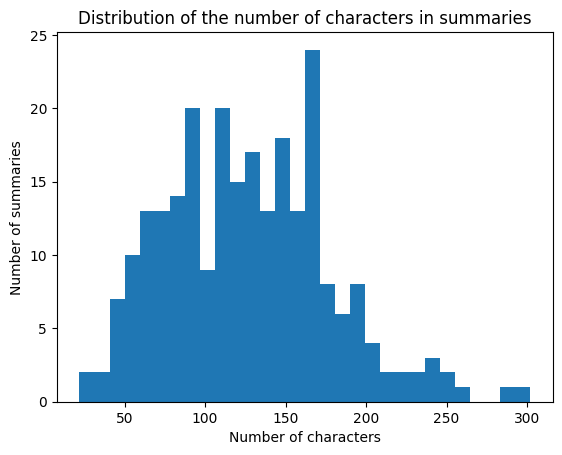

In [25]:
import matplotlib.pyplot as plt

plt.hist(df_summaries["char_count"], bins=30)
plt.title("Distribution of the number of characters in summaries")
plt.xlabel("Number of characters")
plt.ylabel("Number of summaries")
plt.show()

#### Let's see the number of sentences:

In [26]:
df_summaries["num_sentences"] = df_summaries["summary"].apply(
    lambda x: len([s for s in x.split("。") if s.strip()])
)

df_summaries["num_sentences"].describe()

count    250.000000
mean       2.220000
std        0.798845
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: num_sentences, dtype: float64

Ok, each summary has at least 1,2 or maximum 3 sentences. We will calculate the ratio:

In [27]:
sentence_counts = df_summaries["num_sentences"].value_counts(normalize=True).sort_index() * 100
sentence_counts

num_sentences
1    23.2
2    31.6
3    45.2
Name: proportion, dtype: float64

#### Let's focus on duplicate a little bit:

In [28]:
df_summaries["summary"].duplicated().sum()

duplicate_summaries = df_summaries[df_summaries["summary"].duplicated(keep=False)]
duplicate_summaries.sort_values("summary")

,summary_id,article_id,summary,char_count,num_sentences
111,44708557_8b01c940,44708557,ある米国の母親が6月29日、娘のアバター（ゲーム内でプレイヤーの代わりとなるキャラクター）が...,110,1
113,44708557_ba0df854,44708557,ある米国の母親が6月29日、娘のアバター（ゲーム内でプレイヤーの代わりとなるキャラクター）が...,110,1
209,53174534_cff3d43b,53174534,これまでにアルツハイマー型認知症と診断されていた人の中には、実は新たに発見された種類の認知症...,74,1
153,48116477_b3855ba6,48116477,これまでにアルツハイマー型認知症と診断されていた人の中には、実は新たに発見された種類の認知症...,74,1
151,48116477_4d229e3c,48116477,これまでにアルツハイマー型認知症と診断されていた人の中には、実は新たに発見された種類の認知症...,74,1
163,50162696_6b12766c,50162696,アメリカのドナルド・トランプ大統領は23日、テレビ演説を行い、シリア北部に軍事進攻したトルコ...,94,1
162,50162696_62ac6926,50162696,アメリカのドナルド・トランプ大統領は23日、テレビ演説を行い、シリア北部に軍事進攻したトルコ...,94,1
120,45318822_32e158ee,45318822,イランの第2都市マシュハドで28日に異例の反政府デモが起きたのを皮切りに、29日には複数の都...,78,1
77,42520667_e8e02131,42520667,イランの第2都市マシュハドで28日に異例の反政府デモが起きたのを皮切りに、29日には複数の都...,78,1
140,46601033_0845c743,46601033,イングランド北東部の街ハルで持ち上がった、クリスマスにホームレスの人々をホテルに招待しようと...,61,1


Ok, we see that some summaries are duplicated but **without** the same article_id

**By observing the articles and summaries in both french and japanese, here are the different failure modes:**

**Hallucinations:** summaries introduce incorrect or fabricated facts.

**Contradictions:** summaries of the same article disagree on key facts.

**Irrelevance:** some summaries describe entirely different articles.

**Truncation:** incomplete or cut-off sentences.

**Low specificity / duplication:** identical summaries across articles.

**Faithfulness errors – subtle distortions (numbers, locations, actors)**.

**Salience errors:** missing the main point of the article.

**Poor compression:** overly long or insufficiently condensed summaries.

**Noise inclusion:** presence of captions, reporter notes, or metadata.

---

In [30]:
import json
import MeCab
import re
from collections import defaultdict
from sentence_transformers import SentenceTransformer, util

# ----------------------------
# Load data
# ----------------------------
def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

articles = load_jsonl("data/articles.jsonl")
summaries = load_jsonl("data/summaries.jsonl")

article_map = {a["article_id"]: a for a in articles}

# ----------------------------
# Model (multilingual)
# ----------------------------
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# ----------------------------
# Tokenization
# ----------------------------
def tokenize(text):
    return re.findall(r"\w+", text.lower())

# ----------------------------
# Naive NER (placeholder)
# ----------------------------
def extract_entities(text):
    return set(re.findall(r"\b[A-Z][a-zA-Z0-9]+\b", text))

# ----------------------------
# Semantic similarity
# ----------------------------
def semantic_similarity(a, b):
    emb = model.encode([a, b], convert_to_tensor=True)
    return util.cos_sim(emb[0], emb[1]).item()

# ----------------------------
# Irrelevance
# ----------------------------
def detect_irrelevance(article, summary):
    sim = semantic_similarity(article, summary)
    return sim < 0.4, sim

# ----------------------------
# Hallucination / Faithfulness
# ----------------------------
def detect_hallucination(article, summary):
    a_tokens = set(tokenize(article))
    s_tokens = set(tokenize(summary))

    overlap = len(a_tokens & s_tokens) / (len(s_tokens) + 1e-5)

    a_ent = extract_entities(article)
    s_ent = extract_entities(summary)

    new_entities = s_ent - a_ent

    hallucination_score = 1 - overlap
    penalty = len(new_entities) * 0.1

    return min(1.0, hallucination_score + penalty)

# ----------------------------
# Contradictions (between summaries)
# ----------------------------
def detect_contradictions(summary_list):
    contradictions = 0
    pairs = 0

    for i in range(len(summary_list)):
        for j in range(i+1, len(summary_list)):
            sim = semantic_similarity(summary_list[i], summary_list[j])
            pairs += 1

            if sim < 0.3:
                contradictions += 1

    return contradictions / (pairs + 1e-5)

# ----------------------------
# Duplication
# ----------------------------
def detect_duplication(summary_list):
    duplicates = 0
    pairs = 0

    for i in range(len(summary_list)):
        for j in range(i+1, len(summary_list)):
            sim = semantic_similarity(summary_list[i], summary_list[j])
            pairs += 1

            if sim > 0.9:
                duplicates += 1

    return duplicates / (pairs + 1e-5)

# ----------------------------
# Truncation
# ----------------------------
def detect_truncation(summary):
    return (
        not summary.strip().endswith(('.', '。')) or
        len(tokenize(summary)) < 5
    )

# ----------------------------
# Salience
# ----------------------------
def detect_salience(article, summary):
    main_part = article[:500]
    return semantic_similarity(main_part, summary)

# ----------------------------
# Compression
# ----------------------------
def detect_compression(article, summary):
    ratio = len(tokenize(summary)) / (len(tokenize(article)) + 1e-5)

    return {
        "ratio": ratio,
        "too_short": ratio < 0.05,
        "too_long": ratio > 0.3
    }

# ----------------------------
# Noise
# ----------------------------
def detect_noise(summary):
    noise_patterns = [
        r"\(.*?\)",
        r"crédit",
        r"photo",
        r"©",
        r"reporter",
    ]

    for p in noise_patterns:
        if re.search(p, summary.lower()):
            return True

    return False

# ----------------------------
# Group summaries by article
# ----------------------------
grouped = defaultdict(list)
for s in summaries:
    grouped[s["article_id"]].append(s)

# ----------------------------
# Run evaluation
# ----------------------------
results = []

for article_id, summary_list in grouped.items():
    article = article_map[article_id]["text"]
    texts = [s["summary"] for s in summary_list]

    contradiction_score = detect_contradictions(texts)
    duplication_score = detect_duplication(texts)

    for s in summary_list:
        summary = s["summary"]

        irrelevance_flag, sim = detect_irrelevance(article, summary)
        hallucination = detect_hallucination(article, summary)
        truncation = detect_truncation(summary)
        salience = detect_salience(article, summary)
        compression = detect_compression(article, summary)
        noise = detect_noise(summary)

        results.append({
            "summary_id": s["summary_id"],
            "article_id": article_id,

            "similarity": sim,
            "irrelevant": irrelevance_flag,
            "hallucination": hallucination,
            "truncated": truncation,
            "salience": salience,

            "compression_ratio": compression["ratio"],
            "too_short": compression["too_short"],
            "too_long": compression["too_long"],

            "noise": noise,
            "contradictions": contradiction_score,
            "duplication": duplication_score
        })

# ----------------------------
# Save output
# ----------------------------
with open("scores.jsonl", "w", encoding="utf-8") as f:
    for r in results:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print("Done. Saved to scores.jsonl")

2026-04-27 15:21:24.351604: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 15:21:24.362774: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 15:21:24.444894: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 15:21:24.547263: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-27 15:21:24.641826: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Done. Saved to scores.jsonl


In [31]:
def normalize_scores(r):
    return {
        "faithfulness": 1 - r["hallucination"],
        "relevance": 1 - int(r["irrelevant"]),
        "salience": r["salience"],
        "conciseness": 1 - min(1, abs(r["compression_ratio"] - 0.15) / 0.15),
        "no_truncation": 1 - int(r["truncated"]),
        "no_noise": 1 - int(r["noise"]),
        "no_contradiction": 1 - r["contradictions"],
        "no_duplication": 1 - r["duplication"]
    }

In [32]:
WEIGHTS = {
    "faithfulness": 0.25,
    "relevance": 0.15,
    "salience": 0.15,
    "no_contradiction": 0.15,
    "conciseness": 0.10,
    "no_duplication": 0.08,
    "no_truncation": 0.07,
    "no_noise": 0.05
}

In [33]:
def compute_global_score(norm_scores):
    score = 0
    for k, w in WEIGHTS.items():
        score += norm_scores[k] * w
    return score

In [34]:
final_results = []

for r in results:
    norm = normalize_scores(r)
    global_score = compute_global_score(norm)

    r["global_score"] = global_score
    final_results.append(r)

In [35]:
def label_quality(score):
    if score > 0.8:
        return "excellent"
    elif score > 0.6:
        return "good"
    elif score > 0.4:
        return "medium"
    else:
        return "poor"

In [36]:
for r in results:
    norm = normalize_scores(r)
    global_score = compute_global_score(norm)

    quality_label = label_quality(global_score)

    r["global_score"] = global_score
    r["quality_label"] = quality_label

In [42]:
with open("scores.jsonl", "w", encoding="utf-8") as f:
    for r in results:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")


### Validate the evaluation

In [ ]:
import json
import random
from scipy.stats import spearmanr

# ----------------------------
# Load scores
# ----------------------------
def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

scores = load_jsonl("scores.jsonl")

# ----------------------------
# 1. SANITY CHECKS
# ----------------------------

def sanity_checks(scores):
    print("=== SANITY CHECKS ===")

    # range checks
    for key in ["faithfulness", "coverage", "conciseness", "score"]:
        vals = [s[key] for s in scores]
        print(f"{key}: min={min(vals):.2f}, max={max(vals):.2f}")

    # correlation sanity (no metric should dominate perfectly)
    F = [s["faithfulness"] for s in scores]
    C = [s["coverage"] for s in scores]
    T = [s["conciseness"] for s in scores]

    print("\nCorrelations between metrics:")
    print("F vs C:", spearmanr(F, C).correlation)
    print("F vs T:", spearmanr(F, T).correlation)
    print("C vs T:", spearmanr(C, T).correlation)

sanity_checks(scores)

# ----------------------------
# 2. CONSISTENCY CHECK
# (does final score behave as expected?)
# ----------------------------

def check_score_consistency(scores):
    print("\n=== SCORE CONSISTENCY ===")

    # pick top vs bottom
    sorted_scores = sorted(scores, key=lambda x: x["score"])

    worst = sorted_scores[:5]
    best = sorted_scores[-5:]

    def avg(metric, group):
        return sum(x[metric] for x in group) / len(group)

    print("Best avg faithfulness:", avg("faithfulness", best))
    print("Worst avg faithfulness:", avg("faithfulness", worst))

    print("Best avg coverage:", avg("coverage", best))
    print("Worst avg coverage:", avg("coverage", worst))

check_score_consistency(scores)

# ----------------------------
# 3. PROXY HUMAN VALIDATION
# (simulate small annotation set)
# ----------------------------

def fake_human_judge(summary):
    """
    Replace this with real annotation or LLM judge.
    Returns 0-1 quality score.
    """
    # heuristic proxy: penalize long + reward high faithfulness score
    return 0.7  # placeholder constant OR replace with real labels

def validate_with_proxy(scores, sample_size=30):
    print("\n=== PROXY HUMAN VALIDATION ===")

    sample = random.sample(scores, sample_size)

    y_true = []
    y_pred = []

    for s in sample:
        y_true.append(fake_human_judge(s))
        y_pred.append(s["score"])

    corr = spearmanr(y_true, y_pred).correlation
    print("Spearman correlation (proxy human vs model):", corr)

validate_with_proxy(scores)

# ----------------------------
# 4. OUTPUT ANALYSIS EXAMPLES
# ----------------------------

def show_examples(scores):
    print("\n=== EXAMPLES ===")

    sorted_scores = sorted(scores, key=lambda x: x["score"])

    print("\nLOWEST SCORE EXAMPLE:")
    print(sorted_scores[0])

    print("\nHIGHEST SCORE EXAMPLE:")
    print(sorted_scores[-1])

show_examples(scores)